# 单谱宇宙射线清理对照

这个 notebook 只看单条原始谱的宇宙射线清理效果，不做 AsLS、不裁切、不插值、不做组级过滤。

展示内容：

1. 原始谱 vs narrow 清理后
2. narrow 清理后 vs narrow + peak 清理后
3. peak 阶段局部 median 正残差 z-score
4. peak 阶段替换区域局部放大

默认从 `DATASET_NAME` 对应数据集的 `init` 目录随机抽一条 `.arc_data`。如果要固定单条样本，填 `SAMPLE_PATH`；如果要在某个文件夹内随机抽样，填 `SAMPLE_FOLDER`。


In [723]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / "raman").is_dir() and (PROJECT_ROOT / "dataset").is_dir()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

for name in list(sys.modules):
    if name == "raman" or name.startswith("raman."):
        del sys.modules[name]

from raman.data.build import COMMON_BAD_BANDS, DEFAULT_PIPELINE_CONFIG
from raman.data.offline import _median_filter_1d, _odd_window_points, _residual_z_score, remove_cosmic_rays
from raman.data.profiles import get_dataset_dir, get_profile
from raman.data.spectrum import build_valid_mask, read_arc_data

sns.set_theme(style="whitegrid", context="talk", font="Microsoft YaHei")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["figure.figsize"] = (11, 5)

DATASET_NAME = "细菌"
SAMPLE_PATH = "dataset/细菌/delete/Enterobacter/EAB01/cell3_Area01_000_shift.arc_data"
# SAMPLE_PATH = r"E:/Pythonproject/拉曼光谱分类/dataset/细菌/init/Staphylococcus/SHO03/cell9_Area01_001_shift.arc_data"
SAMPLE_FOLDER = None  # 填相对文件夹时只在该文件夹内随机抽样；None 时用 init
SAMPLE_SEED = None  # 设为整数可复现随机抽样

profile = get_profile(DATASET_NAME)
dataset_dir = get_dataset_dir(profile, PROJECT_ROOT)
cfg = DEFAULT_PIPELINE_CONFIG
BAD_BANDS = COMMON_BAD_BANDS

In [724]:
if SAMPLE_PATH:
    sample_path = Path(SAMPLE_PATH)
    if not sample_path.is_absolute():
        sample_path = PROJECT_ROOT / sample_path
    if not sample_path.is_file():
        raise FileNotFoundError(f"样本不存在：{sample_path}")
else:
    if SAMPLE_FOLDER:
        sample_root = Path(SAMPLE_FOLDER)
        if not sample_root.is_absolute():
            sample_root = dataset_dir / sample_root
    else:
        sample_root = dataset_dir / profile.root_init

    matches = sorted(sample_root.rglob("*.arc_data"))
    if not matches:
        raise FileNotFoundError(f"未找到 .arc_data：{sample_root}")
    sample_path = random.Random(SAMPLE_SEED).choice(matches)

wn, sp = read_arc_data(sample_path)
if wn.size == 0 or sp.size == 0:
    raise ValueError(f"读取失败：{sample_path}")

raw = np.asarray(sp, dtype=np.float32)
valid_mask = np.ones_like(wn, dtype=bool)
bad_keep_mask = build_valid_mask(wn, BAD_BANDS)

# 为了画第一阶段结果，这里只复刻 narrow；peak 最终结果直接调用库函数。
narrow_clean = raw.copy()
narrow_mask = np.zeros(raw.shape, dtype=bool)
narrow_window = _odd_window_points(cfg.cosmic_ray_narrow_window_points)
for _ in range(int(cfg.cosmic_ray_max_iter)):
    local_median = _median_filter_1d(narrow_clean, narrow_window)
    residual = narrow_clean - local_median
    z_score = _residual_z_score(residual, valid_mask)
    if z_score is None:
        break

    spike_mask = valid_mask & (z_score > float(cfg.cosmic_ray_threshold))
    if not spike_mask.any():
        break

    narrow_mask |= spike_mask
    narrow_clean[spike_mask] = local_median[spike_mask]

final_clean, final_stats = remove_cosmic_rays(
    raw,
    window_points=cfg.cosmic_ray_narrow_window_points,
    threshold=cfg.cosmic_ray_threshold,
    max_iter=cfg.cosmic_ray_max_iter,
    valid_mask=valid_mask,
    peak_prominence_z=cfg.cosmic_ray_peak_prominence_z,
    peak_window_points=cfg.cosmic_ray_peak_window_points,
    peak_expand_z=cfg.cosmic_ray_peak_expand_z,
    peak_expand_gap_points=cfg.cosmic_ray_peak_expand_gap_points,
    peak_width_max_points=cfg.cosmic_ray_peak_width_max_points,
    peak_mean_z_min=cfg.cosmic_ray_peak_mean_z_min,
    peak_pad_points=cfg.cosmic_ray_peak_pad_points,
)

peak_mask = np.abs(final_clean - narrow_clean) > 1e-6
narrow_final_mask = narrow_mask & ~peak_mask

peak_window = _odd_window_points(cfg.cosmic_ray_peak_window_points)
peak_local_median = _median_filter_1d(narrow_clean, peak_window)
peak_residual = narrow_clean - peak_local_median
peak_residual_z = _residual_z_score(peak_residual, valid_mask)
if peak_residual_z is None:
    peak_residual_z = np.full(raw.shape, np.nan, dtype=np.float32)

peak_segments = []
peak_indices = np.flatnonzero(peak_mask & valid_mask)
if peak_indices.size:
    for part in np.split(peak_indices, np.where(np.diff(peak_indices) > 1)[0] + 1):
        start = int(part[0])
        end = int(part[-1]) + 1
        z_segment = peak_residual_z[start:end]
        before = narrow_clean[start:end]
        after = final_clean[start:end]
        peak_segments.append(
            {
                "start": start,
                "end": end,
                "wn_min": float(wn[start]),
                "wn_max": float(wn[end - 1]),
                "width_points": int(end - start),
                "max_z": float(np.nanmax(z_segment)) if z_segment.size else np.nan,
                "mean_z": float(np.nanmean(np.maximum(z_segment, 0.0))) if z_segment.size else np.nan,
                "delta_mean": float(np.mean(before - after)) if before.size else 0.0,
            }
        )

print(f"project_root = {PROJECT_ROOT}")
print(f"dataset_dir = {dataset_dir}")
print(f"sample_path = {sample_path}")
print(f"bad_bands = {BAD_BANDS}")
print(
    f"narrow：window_points={cfg.cosmic_ray_narrow_window_points}, "
    f"threshold={cfg.cosmic_ray_threshold}, max_iter={cfg.cosmic_ray_max_iter}"
)
print(
    "peak 段扩展："
    f"core_z>={cfg.cosmic_ray_peak_prominence_z}, "
    f"expand_z>={cfg.cosmic_ray_peak_expand_z}, "
    f"gap_points<={cfg.cosmic_ray_peak_expand_gap_points}, "
    f"window_points={cfg.cosmic_ray_peak_window_points}, "
    f"width_points<={cfg.cosmic_ray_peak_width_max_points}, "
    f"mean_z>={cfg.cosmic_ray_peak_mean_z_min}, "
    f"pad_points={cfg.cosmic_ray_peak_pad_points}"
)
print(f"narrow 最终替换点数：{final_stats.narrow}")
print(f"peak 最终替换点数：{final_stats.peak}")
print(f"peak 异常段数量：{len(peak_segments)}")
print(f"最终总替换点数：{final_stats.total}")

project_root = E:\Pythonproject\拉曼光谱分类
dataset_dir = E:\Pythonproject\拉曼光谱分类\dataset\细菌
sample_path = E:\Pythonproject\拉曼光谱分类\dataset\细菌\delete\Enterobacter\EAB01\cell3_Area01_000_shift.arc_data
bad_bands = ((890.0, 950.0),)
narrow：window_points=9, threshold=7.0, max_iter=2
peak 段扩展：core_z>=9.2, expand_z>=4.0, gap_points<=2, window_points=31, width_points<=15, mean_z>=6.0, pad_points=1
narrow 最终替换点数：12
peak 最终替换点数：29
peak 异常段数量：2
最终总替换点数：41


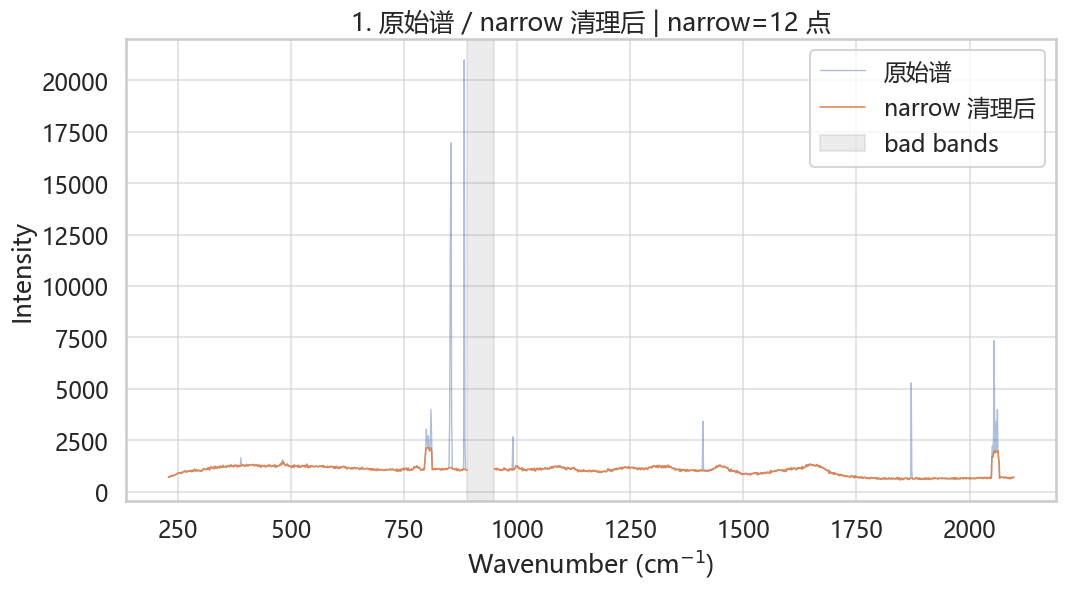

In [725]:
# 1. 原始谱和 narrow 结果
raw_plot = raw.copy()
narrow_plot = narrow_clean.copy()
raw_plot[~bad_keep_mask] = np.nan
narrow_plot[~bad_keep_mask] = np.nan

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wn, raw_plot, label="原始谱", alpha=0.45, linewidth=1.0)
ax.plot(wn, narrow_plot, label="narrow 清理后", alpha=0.95, linewidth=1.2)
for idx, (band_min, band_max) in enumerate(BAD_BANDS):
    ax.axvspan(band_min, band_max, color="gray", alpha=0.15, label="bad bands" if idx == 0 else None)
ax.set_title(f"1. 原始谱 / narrow 清理后 | narrow={int(narrow_final_mask.sum())} 点")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend(loc="best")
plt.show()

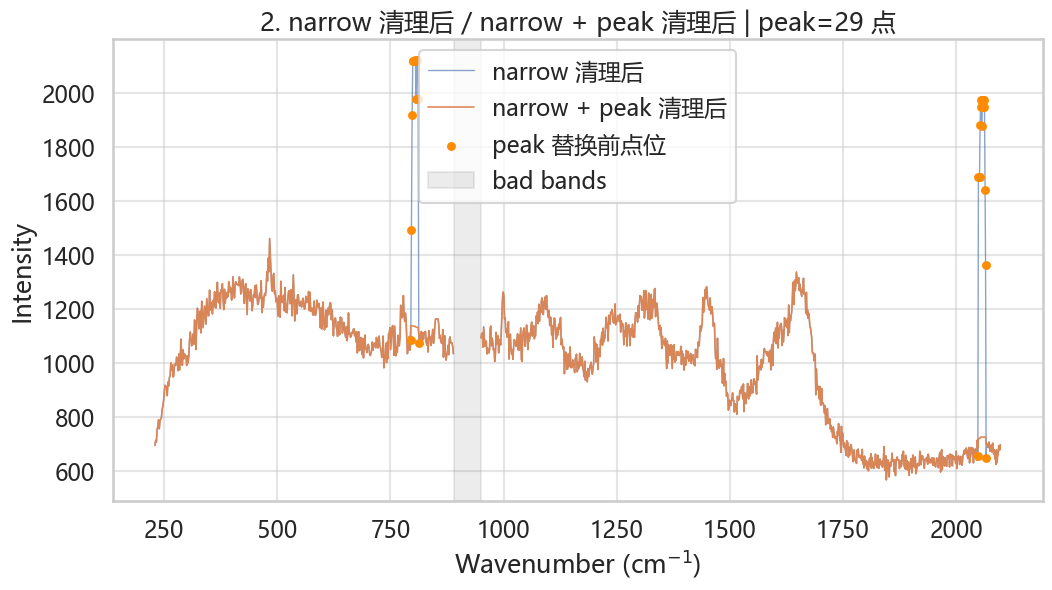

In [726]:
# 2. narrow 结果和 narrow + peak 结果
narrow_plot = narrow_clean.copy()
final_plot = final_clean.copy()
narrow_plot[~bad_keep_mask] = np.nan
final_plot[~bad_keep_mask] = np.nan
visible_peak_mask = peak_mask & bad_keep_mask

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wn, narrow_plot, label="narrow 清理后", alpha=0.65, linewidth=1.0)
ax.plot(wn, final_plot, label="narrow + peak 清理后", alpha=0.95, linewidth=1.2)
if visible_peak_mask.any():
    ax.scatter(wn[visible_peak_mask], narrow_clean[visible_peak_mask], s=24, color="darkorange", label="peak 替换前点位", zorder=5)
else:
    ax.text(0.02, 0.92, "当前样本没有可见的 peak 替换点", transform=ax.transAxes)
for idx, (band_min, band_max) in enumerate(BAD_BANDS):
    ax.axvspan(band_min, band_max, color="gray", alpha=0.15, label="bad bands" if idx == 0 else None)
ax.set_title(f"2. narrow 清理后 / narrow + peak 清理后 | peak={int(peak_mask.sum())} 点")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend(loc="best")
plt.show()

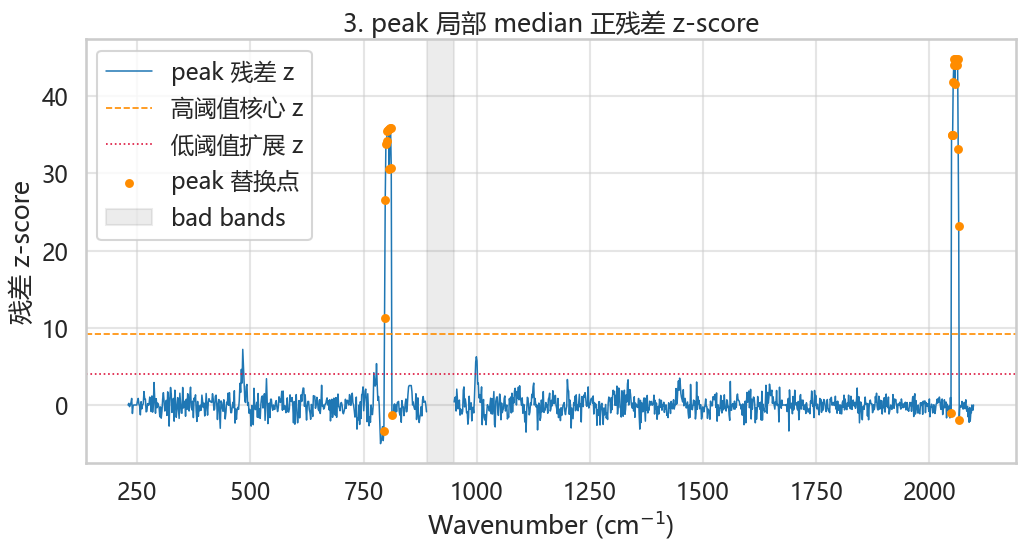

In [727]:
# 3. peak 阶段局部 median 正残差 z-score
z_plot = peak_residual_z.copy()
z_plot[~bad_keep_mask] = np.nan
visible_peak_mask = peak_mask & bad_keep_mask

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(wn, z_plot, label="peak 残差 z", color="tab:blue", linewidth=1.1)
ax.axhline(cfg.cosmic_ray_peak_prominence_z, color="darkorange", linestyle="--", linewidth=1.2, label="高阈值核心 z")
ax.axhline(cfg.cosmic_ray_peak_expand_z, color="crimson", linestyle=":", linewidth=1.2, label="低阈值扩展 z")
if visible_peak_mask.any():
    ax.scatter(wn[visible_peak_mask], peak_residual_z[visible_peak_mask], s=24, color="darkorange", label="peak 替换点", zorder=5)
else:
    ax.text(0.02, 0.92, "当前样本没有可见的 peak 替换点", transform=ax.transAxes)
for idx, (band_min, band_max) in enumerate(BAD_BANDS):
    ax.axvspan(band_min, band_max, color="gray", alpha=0.15, label="bad bands" if idx == 0 else None)
ax.set_title("3. peak 局部 median 正残差 z-score")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("残差 z-score")
ax.legend(loc="best")
plt.show()

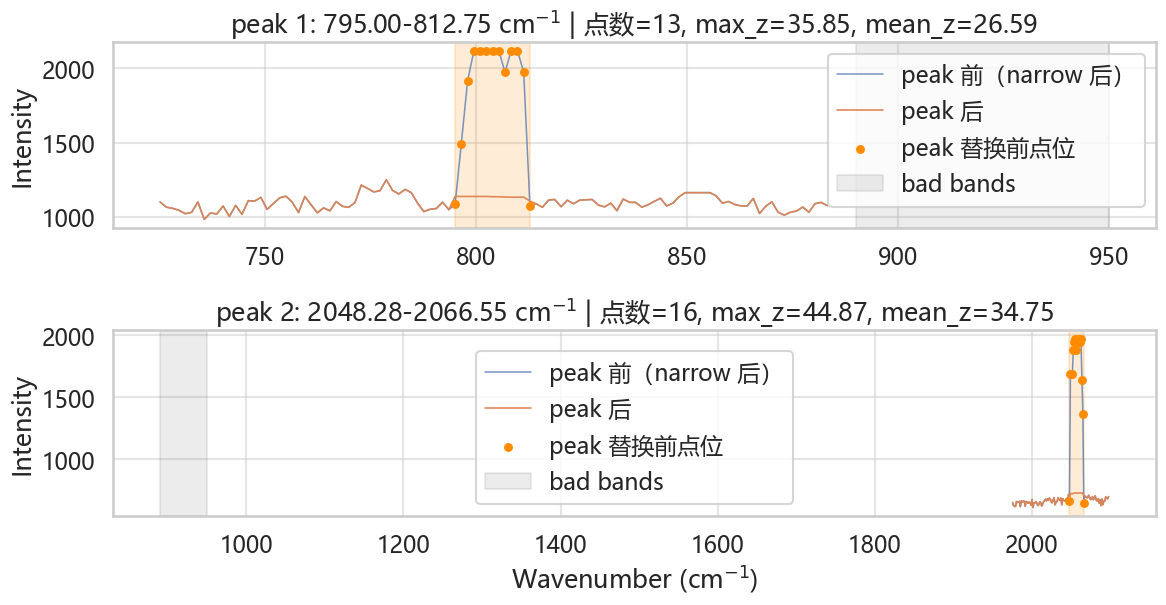

In [728]:
# 4. peak 阶段替换区域局部放大；默认最多展示前 6 段
segments = peak_segments[:6]

if not segments:
    print("当前样本没有可见的 peak 阶段替换区域可放大")
else:
    fig, axes = plt.subplots(len(segments), 1, figsize=(12, 3.2 * len(segments)), squeeze=False)
    axes = axes[:, 0]
    for idx, (ax, segment) in enumerate(zip(axes, segments), start=1):
        start = segment["start"]
        end = segment["end"]
        wn_min = segment["wn_min"]
        wn_max = segment["wn_max"]
        pad = max((wn_max - wn_min) * 4, 20.0)
        local = (wn >= wn_min - pad) & (wn <= wn_max + pad)
        local_keep = build_valid_mask(wn[local], BAD_BANDS)
        before_plot = narrow_clean[local].copy()
        after_plot = final_clean[local].copy()
        before_plot[~local_keep] = np.nan
        after_plot[~local_keep] = np.nan

        ax.plot(wn[local], before_plot, label="peak 前（narrow 后）", alpha=0.75, linewidth=1.1)
        ax.plot(wn[local], after_plot, label="peak 后", alpha=0.95, linewidth=1.2)
        ax.scatter(wn[start:end], narrow_clean[start:end], s=24, color="darkorange", label="peak 替换前点位", zorder=5)
        ax.axvspan(wn_min, wn_max, color="darkorange", alpha=0.16)
        for band_idx, (band_min, band_max) in enumerate(BAD_BANDS):
            ax.axvspan(band_min, band_max, color="gray", alpha=0.15, label="bad bands" if band_idx == 0 else None)
        ax.set_title(
            f"peak {idx}: {wn_min:.2f}-{wn_max:.2f} cm$^{{-1}}$ | "
            f"点数={segment['width_points']}, max_z={segment['max_z']:.2f}, mean_z={segment['mean_z']:.2f}"
        )
        ax.set_ylabel("Intensity")
        ax.legend(loc="best")

    axes[-1].set_xlabel("Wavenumber (cm$^{-1}$)")
    plt.tight_layout()
    plt.show()